In [13]:
!pip install ucimlrepo -q

import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# n seed ayari
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# grafik temalari
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["figure.dpi"] = 110

# spambase veri seti
dataset = fetch_ucirepo(id=94)

X = dataset.data.features
y = dataset.data.targets.squeeze()

print(f"veri boyutu: {X.shape}")
print("sinif dagilimi:")
print(y.value_counts())
X.head()

veri boyutu: (4601, 57)
sinif dagilimi:
Class
0    2788
1    1813
Name: count, dtype: int64


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191


                    count  mean   std  min  25%  50%   75%    max
word_freq_make     4601.0  0.10  0.31  0.0  0.0  0.0  0.00   4.54
word_freq_address  4601.0  0.21  1.29  0.0  0.0  0.0  0.00  14.28
word_freq_all      4601.0  0.28  0.50  0.0  0.0  0.0  0.42   5.10
word_freq_3d       4601.0  0.07  1.40  0.0  0.0  0.0  0.00  42.81
word_freq_our      4601.0  0.31  0.67  0.0  0.0  0.0  0.38  10.00
word_freq_over     4601.0  0.10  0.27  0.0  0.0  0.0  0.00   5.88


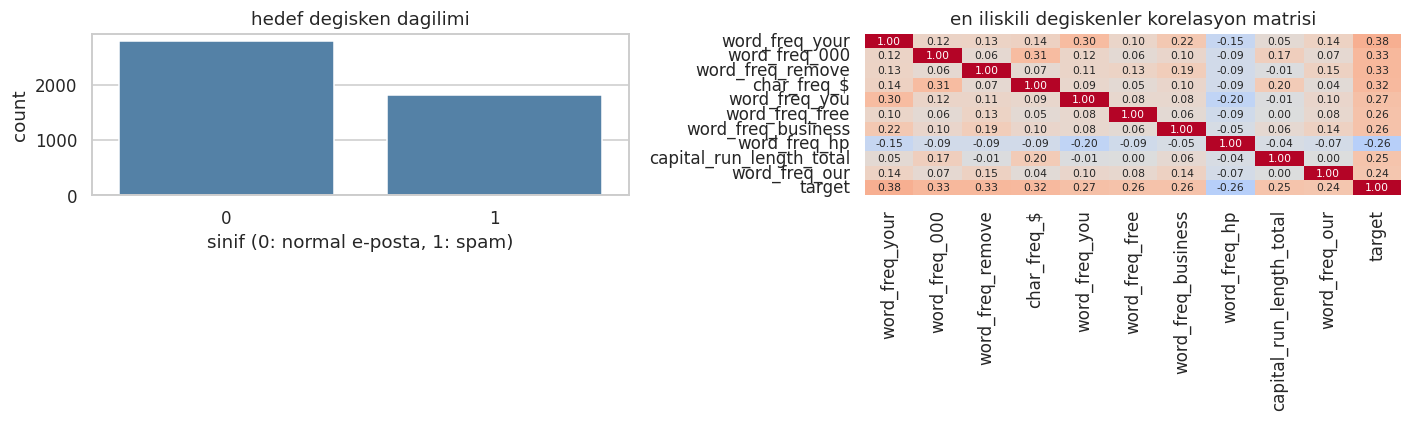

In [14]:

print(X.iloc[:, :6].describe().T.round(2))

# hedef degisken dagilimi ve korelasyon gorsellestirmesi
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 1. grafik: sinif dagilimi
sns.countplot(x=y, ax=axes[0], color="steelblue")
axes[0].set_title("hedef degisken dagilimi")
axes[0].set_xlabel("sinif (0: normal e-posta, 1: spam)")

# 2. grafik: hedefle en iliskili 10 degiskenin korelasyonu
top_corr_features = X.corrwith(y).abs().nlargest(10).index
corr = pd.concat([X[top_corr_features], y.rename("target")], axis=1).corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=axes[1], cbar=False, annot_kws={"size": 7})
axes[1].set_title("en iliskili degiskenler korelasyon matrisi")

plt.tight_layout()
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

#  egitim ve test olarak ayırma
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)


siniflandiricilar = {
    "Baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Karar agaci": DecisionTreeClassifier(random_state=SEED),
    "Rastgele orman": RandomForestClassifier(random_state=SEED)
}

satirlar = []

for ad, m in siniflandiricilar.items():
    m.fit(Xc_train, yc_train)
    satirlar.append({
        "Model": ad,
        "Egitim": accuracy_score(yc_train, m.predict(Xc_train)),
        "Test": accuracy_score(yc_test, m.predict(Xc_test))
    })

sonuclar_df = pd.DataFrame(satirlar).set_index("Model").round(3)
sonuclar_df

,Egitim,Test
Model,,
Baseline,0.606,0.606
Logistic,0.933,0.927
KNN,0.870,0.799
Karar agaci,1.000,0.911
Rastgele orman,1.000,0.945


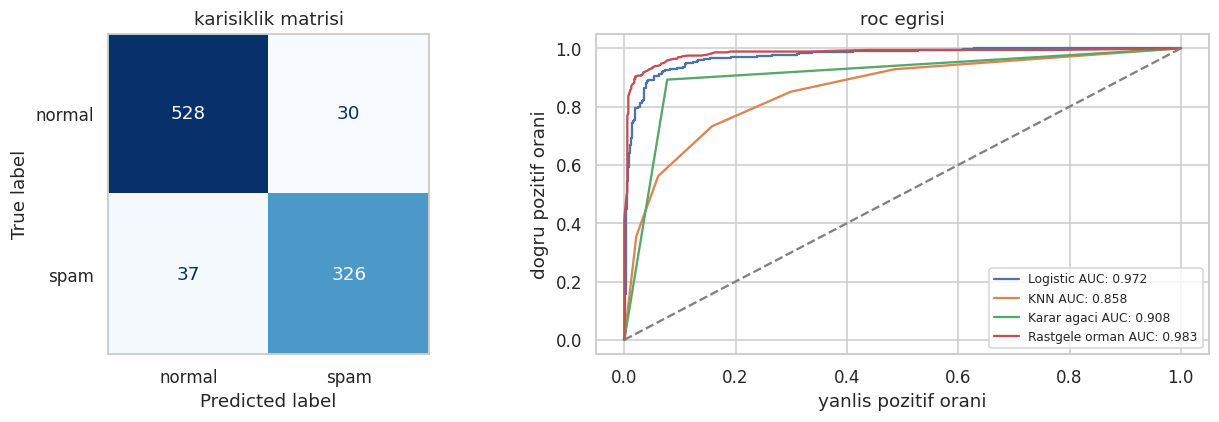

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

# lojistik regresyon tahminleri
model = siniflandiricilar["Logistic"]
tahmin = model.predict(Xc_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. grafik: confusion matrisi
cm = confusion_matrix(yc_test, tahmin)
ConfusionMatrixDisplay.from_predictions(
    yc_test, tahmin, display_labels=["normal", "spam"], cmap="Blues", ax=axes[0], colorbar=False
)
axes[0].set_title("karisiklik matrisi")
axes[0].grid(False)

# 2. grafik: roc egrileri
for ad in ["Logistic", "KNN", "Karar agaci", "Rastgele orman"]:
    p = siniflandiricilar[ad].predict_proba(Xc_test)[:, 1]
    fpr, tpr, _ = roc_curve(yc_test, p)
    axes[1].plot(fpr, tpr, label=f"{ad} AUC: {roc_auc_score(yc_test, p):.3f}")

axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("yanlis pozitif orani")
axes[1].set_ylabel("dogru pozitif orani")
axes[1].set_title("roc egrisi")
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [17]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 5 katli tabakali capraz dogrulama
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

satirlar = []

for ad, m in siniflandiricilar.items():
    skorlar = cross_val_score(m, Xc_train, yc_train, cv=cv, scoring="accuracy")
    satirlar.append({
        "Model": ad,
        "Ortalama skor": skorlar.mean(),
        "Standart sapma": skorlar.std()
    })

cv_sonuc = pd.DataFrame(satirlar).set_index("Model").sort_values("Ortalama skor", ascending=False).round(3)
display(cv_sonuc)

,Ortalama skor,Standart sapma
Model,,
Rastgele orman,0.952,0.005
Logistic,0.926,0.009
Karar agaci,0.914,0.010
KNN,0.792,0.017
Baseline,0.606,0.000


In [20]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV


pipe = make_pipeline(StandardScaler(), KNeighborsClassifier())

# taranacak hiperparametreler
param_grid = {
    "kneighborsclassifier__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21],
    "kneighborsclassifier__weights": ["uniform", "distance"]
}

# grid search optimizasyonu
opt = GridSearchCV(pipe, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
opt.fit(Xc_train, yc_train)

print("best parametre:", opt.best_params_)
print(f"en iyi cv: {opt.best_score_:.3f}")

best parametre: {'kneighborsclassifier__n_neighbors': 9, 'kneighborsclassifier__weights': 'distance'}
en iyi cv: 0.921


In [21]:
from sklearn.metrics import classification_report

# en iyi model ile test seti uzerinde tahmin
en_iyi_model = opt.best_estimator_
y_tahmin_test = en_iyi_model.predict(Xc_test)

test_dogruluk = en_iyi_model.score(Xc_test, yc_test)
print(f"optimizasyon sonrasi test dogrulugu: {test_dogruluk:.4f}\n")

print("detayli siniflandirma raporu:")
print(classification_report(yc_test, y_tahmin_test, target_names=["normal", "spam"]))

optimizasyon sonrasi test dogrulugu: 0.9164

detayli siniflandirma raporu:
              precision    recall  f1-score   support

      normal       0.93      0.93      0.93       558
        spam       0.90      0.89      0.89       363

    accuracy                           0.92       921
   macro avg       0.91      0.91      0.91       921
weighted avg       0.92      0.92      0.92       921



In [23]:

scaler_yanlis = StandardScaler().fit(X)
Xc_tr_yanlis = scaler_yanlis.transform(Xc_train)
Xc_te_yanlis = scaler_yanlis.transform(Xc_test)


scaler_dogru = StandardScaler().fit(Xc_train)
Xc_tr_dogru = scaler_dogru.transform(Xc_train)
Xc_te_dogru = scaler_dogru.transform(Xc_test)

print("yanlis yontem ortalamalari (ilk 5 ozellik):")
print(scaler_yanlis.mean_[:5].round(3))

print("\ndogru yontem ortalamalari (ilk 5 ozellik):")
print(scaler_dogru.mean_[:5].round(3))

yanlis yontem ortalamalari (ilk 5 ozellik):
[0.105 0.213 0.281 0.065 0.312]

dogru yontem ortalamalari (ilk 5 ozellik):
[0.108 0.218 0.274 0.07  0.316]


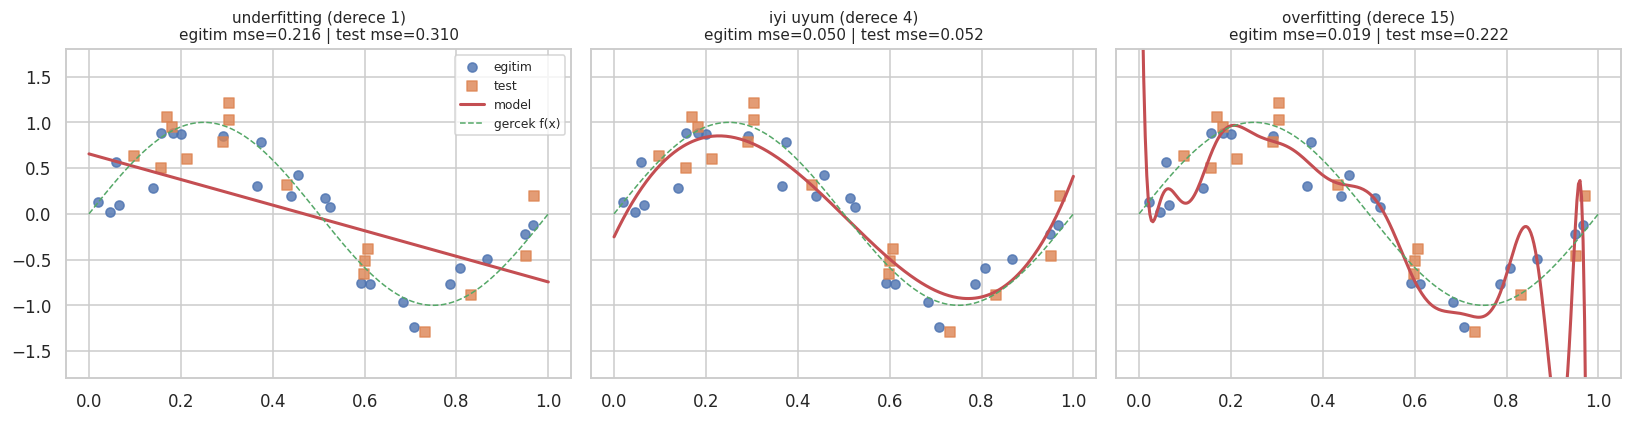

In [24]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# sentetik veri kumesi
rng = np.random.RandomState(SEED)
n = 40
x = np.sort(rng.uniform(0, 1, n))
y_poly = np.sin(2 * np.pi * x) + rng.normal(0, 0.25, n)

x_tr, x_te, y_tr, y_te = train_test_split(x.reshape(-1, 1), y_poly, test_size=0.4, random_state=SEED)

xs = np.linspace(0, 1, 300).reshape(-1, 1)
dereceler = [1, 4, 15]
basliklar = ["underfitting (derece 1)", "iyi uyum (derece 4)", "overfitting (derece 15)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, d, b in zip(axes, dereceler, basliklar):
    model = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    model.fit(x_tr, y_tr)
    tr_hata = mean_squared_error(y_tr, model.predict(x_tr))
    te_hata = mean_squared_error(y_te, model.predict(x_te))

    ax.scatter(x_tr, y_tr, label="egitim", alpha=0.8)
    ax.scatter(x_te, y_te, label="test", alpha=0.8, marker="s")
    ax.plot(xs, model.predict(xs), "r-", lw=2, label="model")
    ax.plot(xs, np.sin(2 * np.pi * xs), "g--", lw=1, label="gercek f(x)")
    ax.set_ylim(-1.8, 1.8)
    ax.set_title(f"{b}\negitim mse={tr_hata:.3f} | test mse={te_hata:.3f}", fontsize=10)

axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score


scaler_km = StandardScaler()
X_scaled = scaler_km.fit_transform(X)

# k=2
kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=10)
kume_etiketleri = kmeans.fit_predict(X_scaled)

sil_skor = silhouette_score(X_scaled, kume_etiketleri)
ari_skor = adjusted_rand_score(y, kume_etiketleri)

print(f"silhouette skoru: {sil_skor:.3f}")
print(f"adjusted rand index (gercek siniflarla uyum): {ari_skor:.3f}")


karsilastirma = pd.crosstab(y, kume_etiketleri, rownames=['Gercek'], colnames=['Kume'])
display(karsilastirma)

silhouette skoru: 0.660
adjusted rand index (gercek siniflarla uyum): -0.005


Kume,0,1
Gercek,,
0,34,2754
1,0,1813


In [27]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor

# Surekli hedef degisken olarak buyuk harf toplamini tahmin
# Ozellikler: Kelime ve karakter frekanslari
# Hedef: capital_run_length_total (sayisal surekli deger)
X_reg = X.iloc[:, :54]
y_reg = X['capital_run_length_total']

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=SEED
)


def regresyon_raporu(model, X_val, y_val, ad):
    tahmin = model.predict(X_val)
    return {
        "Model": ad,
        "Mae": mean_absolute_error(y_val, tahmin),
        "mse": mean_squared_error(y_val, tahmin),
        "rmse": np.sqrt(mean_squared_error(y_val, tahmin)),
        "r2": r2_score(y_val, tahmin)
    }

#  Dummy (Baseline), Linear, Ridge, Lasso
reg_modeller = {
    "Baseline": DummyRegressor(strategy="mean"),
    "Linear": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Lasso": make_pipeline(StandardScaler(), Lasso(alpha=1.0))
}

reg_satirlar = []
for ad, m in reg_modeller.items():
    m.fit(Xr_train, yr_train)
    reg_satirlar.append(regresyon_raporu(m, Xr_test, yr_test, ad))

reg_sonuc_df = pd.DataFrame(reg_satirlar).set_index("Model").round(3)
display(reg_sonuc_df)

,Mae,mse,rmse,r2
Model,,,,
Baseline,317.216,556710.061,746.130,-0.001
Linear,269.716,517665.147,719.490,0.069
Ridge,269.713,517653.248,719.481,0.069
Lasso,268.342,517018.704,719.040,0.071


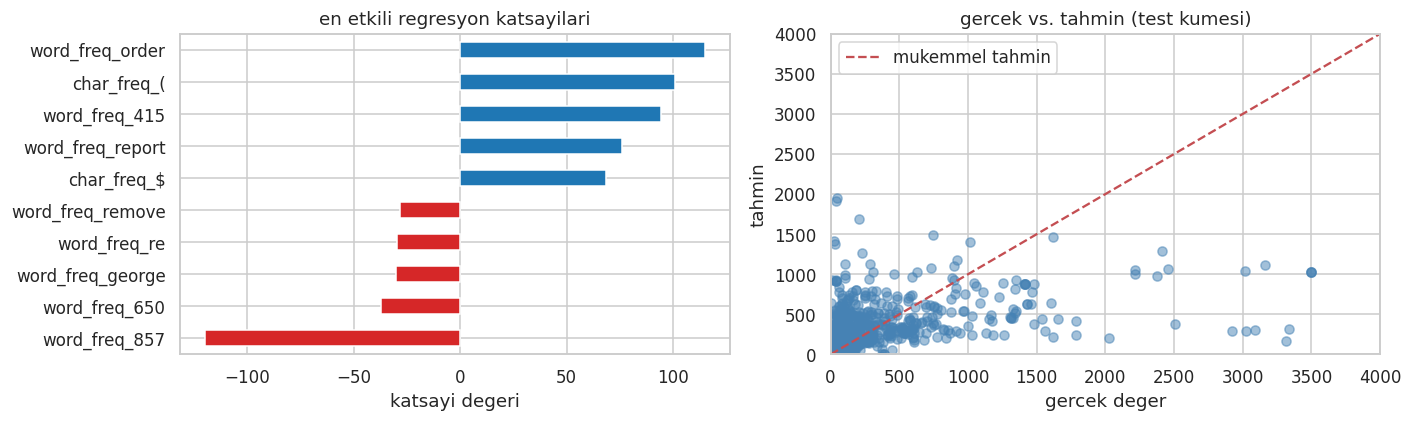

In [29]:
# 1. Grafik: En etkili regresyon katsayilari
ridge_model = reg_modeller["Ridge"].named_steps["ridge"]
katsayilar = pd.Series(ridge_model.coef_, index=X_reg.columns)

en_etkili = pd.concat([katsayilar.nlargest(5), katsayilar.nsmallest(5)]).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

en_etkili.plot(kind="barh", color=np.where(en_etkili > 0, "tab:blue", "tab:red"), ax=axes[0])
axes[0].set_title("en etkili regresyon katsayilari")
axes[0].set_xlabel("katsayi degeri")

# 2. Grafik: Gercek vs. Tahmin
tahmin_linear = reg_modeller["Linear"].predict(Xr_test)

axes[1].scatter(yr_test, tahmin_linear, alpha=0.5, color="steelblue")
limler = [0, 4000]
axes[1].plot(limler, limler, "r--", label="mukemmel tahmin")
axes[1].set_xlim(limler)
axes[1].set_ylim(limler)
axes[1].set_xlabel("gercek deger")
axes[1].set_ylabel("tahmin")
axes[1].set_title("gercek vs. tahmin (test kumesi)")
axes[1].legend()

plt.tight_layout()
plt.show()